# 🔍 Customer Churn Analysis

## Understanding Customer Behaviour and Churn Risk

Customer churn is one of the most important challenges facing subscription-based businesses. Retaining existing customers is often significantly more cost-effective than acquiring new ones.

In this project, I explore customer consumption behaviour, pricing patterns and customer account characteristics to uncover insights that may explain why customers choose to leave.

### Business Objectives

- Explore customer and pricing datasets.
- Understand the structure and quality of the data.
- Analyse customer consumption behaviour.
- Investigate pricing trends and patterns.
- Examine customer churn distribution.
- Prepare the data for future predictive modelling.

### Skills Demonstrated

- Python
- Pandas
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualisation
- Business Analytics
- Customer Churn Analysis

---

## 🛠 Importing Required Libraries

Before beginning the analysis, we import the libraries required for data manipulation, visualisation and exploratory data analysis.

These tools will help us efficiently explore the datasets and communicate findings through visual storytelling.

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [5]:
import piplite
await piplite.install("seaborn")

In [6]:
import seaborn as sns

In [7]:
import matplotlib.pyplot as plt

In [8]:
sns.set_style("whitegrid")

In [9]:
print("Seaborn loaded successfully!")

Seaborn loaded successfully!


In [11]:
pd.set_option('display.max_columns', None)


In [12]:
import warnings
warnings.filterwarnings('ignore')

## 📂 Loading the Data

The project consists of two primary datasets:

### Customer Dataset
Contains customer characteristics, electricity consumption, subscription information and business-related attributes.

### Pricing Dataset
Contains historical pricing information across different pricing periods.

The first step is to load these datasets into Pandas DataFrames for analysis.

In [13]:
client_df = pd.read_csv("client_data (1).csv")
price_df = pd.read_csv("price_data (1).csv")

## First Look at the Data

Before performing any analysis, it is important to understand the size and structure of the datasets.

This initial inspection allows us to answer several key questions:

- How many observations are available?
- How many variables are present?
- Does the data appear complete?
- Are there any immediate quality concerns?

A quick overview provides valuable context for the remainder of the analysis.

In [15]:
print(client_df.shape)
print(price_df.shape)

client_df.head()

(14606, 26)
(193002, 8)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


## 🏗 Understanding Available Features

Every variable tells part of the customer story.

In this section, we review all available features to better understand:

- Customer characteristics
- Consumption behaviour
- Pricing information
- Contract-related dates
- Churn outcomes

This understanding helps guide further exploration and feature engineering.

In [16]:
client_df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')

In [17]:
price_df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

## Exploring Dataset Structure

Understanding data types is an essential part of exploratory analysis.

Here we examine:

- Data types
- Missing values
- Dataset dimensions
- Variable structure

Correctly identifying data types ensures that appropriate analytical techniques are applied later in the project.

In [18]:
client_df.info

<bound method DataFrame.info of                                      id                     channel_sales  \
0      24011ae4ebbe3035111d65fa7c15bc57  foosdfpfkusacimwkcsosbicdxkicaua   
1      d29c2c54acc38ff3c0614d0a653813dd                           MISSING   
2      764c75f661154dac3a6c254cd082ea7d  foosdfpfkusacimwkcsosbicdxkicaua   
3      bba03439a292a1e166f80264c16191cb  lmkebamcaaclubfxadlmueccxoimlema   
4      149d57cf92fc41cf94415803a877cb4b                           MISSING   
...                                 ...                               ...   
14601  18463073fb097fc0ac5d3e040f356987  foosdfpfkusacimwkcsosbicdxkicaua   
14602  d0a6f71671571ed83b2645d23af6de00  foosdfpfkusacimwkcsosbicdxkicaua   
14603  10e6828ddd62cbcf687cb74928c4c2d2  foosdfpfkusacimwkcsosbicdxkicaua   
14604  1cf20fd6206d7678d5bcafd28c53b4db  foosdfpfkusacimwkcsosbicdxkicaua   
14605  563dde550fd624d7352f3de77c0cdfcd                           MISSING   

       cons_12m  cons_gas_12m  cons_last_mo

In [19]:
price_df.info

<bound method DataFrame.info of                                       id  price_date  price_off_peak_var  \
0       038af19179925da21a25619c5a24b745  2015-01-01            0.151367   
1       038af19179925da21a25619c5a24b745  2015-02-01            0.151367   
2       038af19179925da21a25619c5a24b745  2015-03-01            0.151367   
3       038af19179925da21a25619c5a24b745  2015-04-01            0.149626   
4       038af19179925da21a25619c5a24b745  2015-05-01            0.149626   
...                                  ...         ...                 ...   
192997  16f51cdc2baa19af0b940ee1b3dd17d5  2015-08-01            0.119916   
192998  16f51cdc2baa19af0b940ee1b3dd17d5  2015-09-01            0.119916   
192999  16f51cdc2baa19af0b940ee1b3dd17d5  2015-10-01            0.119916   
193000  16f51cdc2baa19af0b940ee1b3dd17d5  2015-11-01            0.119916   
193001  16f51cdc2baa19af0b940ee1b3dd17d5  2015-12-01            0.119916   

        price_peak_var  price_mid_peak_var  price_off_p

## Exploring Dataset Structure

Understanding data types is an essential part of exploratory analysis.

Here we examine:

- Data types
- Missing values
- Dataset dimensions
- Variable structure

Correctly identifying data types ensures that appropriate analytical techniques are applied later in the project.

In [20]:
client_df.dtypes

id                                 object
channel_sales                      object
cons_12m                            int64
cons_gas_12m                        int64
cons_last_month                     int64
date_activ                         object
date_end                           object
date_modif_prod                    object
date_renewal                       object
forecast_cons_12m                 float64
forecast_cons_year                  int64
forecast_discount_energy          float64
forecast_meter_rent_12m           float64
forecast_price_energy_off_peak    float64
forecast_price_energy_peak        float64
forecast_price_pow_off_peak       float64
has_gas                            object
imp_cons                          float64
margin_gross_pow_ele              float64
margin_net_pow_ele                float64
nb_prod_act                         int64
net_margin                        float64
num_years_antig                     int64
origin_up                         

In [21]:
price_df.dtypes

id                     object
price_date             object
price_off_peak_var    float64
price_peak_var        float64
price_mid_peak_var    float64
price_off_peak_fix    float64
price_peak_fix        float64
price_mid_peak_fix    float64
dtype: object

In [22]:
client_datatypes = pd.DataFrame({
    'Column': client_df.columns,
    'Data Type': client_df.dtypes.values
})

client_datatypes

,Column,Data Type
0,id,object
1,channel_sales,object
2,cons_12m,int64
3,cons_gas_12m,int64
4,cons_last_month,int64
5,date_activ,object
6,date_end,object
7,date_modif_prod,object
8,date_renewal,object
9,forecast_cons_12m,float64


In [23]:
price_datatypes = pd.DataFrame({
    'Column': price_df.columns,
    'Data Type': price_df.dtypes.values
})

price_datatypes

,Column,Data Type
0,id,object
1,price_date,object
2,price_off_peak_var,float64
3,price_peak_var,float64
4,price_mid_peak_var,float64
5,price_off_peak_fix,float64
6,price_peak_fix,float64
7,price_mid_peak_fix,float64


In [25]:
date_columns = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

for col in date_columns:
    client_df[col] = pd.to_datetime(client_df[col])

In [26]:
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

In [27]:
client_df.info()
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

## 📈 Statistical Overview

Summary statistics provide a high-level snapshot of customer behaviour and business performance.

Key measures include:

- Average consumption
- Revenue-related metrics
- Customer tenure
- Distribution ranges

This overview helps identify unusual values and potential business insights.

In [28]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606,14606,14606,14606,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,2011-01-28 07:54:18.879912448,2016-07-27 20:48:26.422018560,2013-01-02 12:29:10.951663872,2015-07-21 06:59:00.353279488,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
min,0.000000e+00,0.000000e+00,0.000000,2003-05-09 00:00:00,2016-01-28 00:00:00,2003-05-09 00:00:00,2013-06-26 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,2010-01-15 00:00:00,2016-04-27 06:00:00,2010-08-12 00:00:00,2015-04-17 00:00:00,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,2011-03-04 00:00:00,2016-08-01 00:00:00,2013-06-19 00:00:00,2015-07-27 00:00:00,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2012-04-19 00:00:00,2016-10-31 00:00:00,2015-06-16 00:00:00,2015-10-29 00:00:00,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,2014-09-01 00:00:00,2017-06-13 00:00:00,2016-01-29 00:00:00,2016-01-28 00:00:00,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000
std,5.734653e+05,1.629731e+05,64364.196422,NaN,NaN,NaN,NaN,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175


In [29]:
price_df.describe()

,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,2015-06-16 12:50:49.933161216,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
min,2015-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 00:00:00,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,2015-07-01 00:00:00,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,2015-10-01 00:00:00,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,2015-12-01 00:00:00,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221
std,NaN,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592


## 📉 Exploring Numerical Distributions

Data distributions reveal how customers behave across different variables.

By visualising distributions, we can identify:

- Common customer behaviours
- Skewed variables
- Extreme observations
- Potential modelling challenges

Understanding these patterns is a critical step in exploratory data analysis.

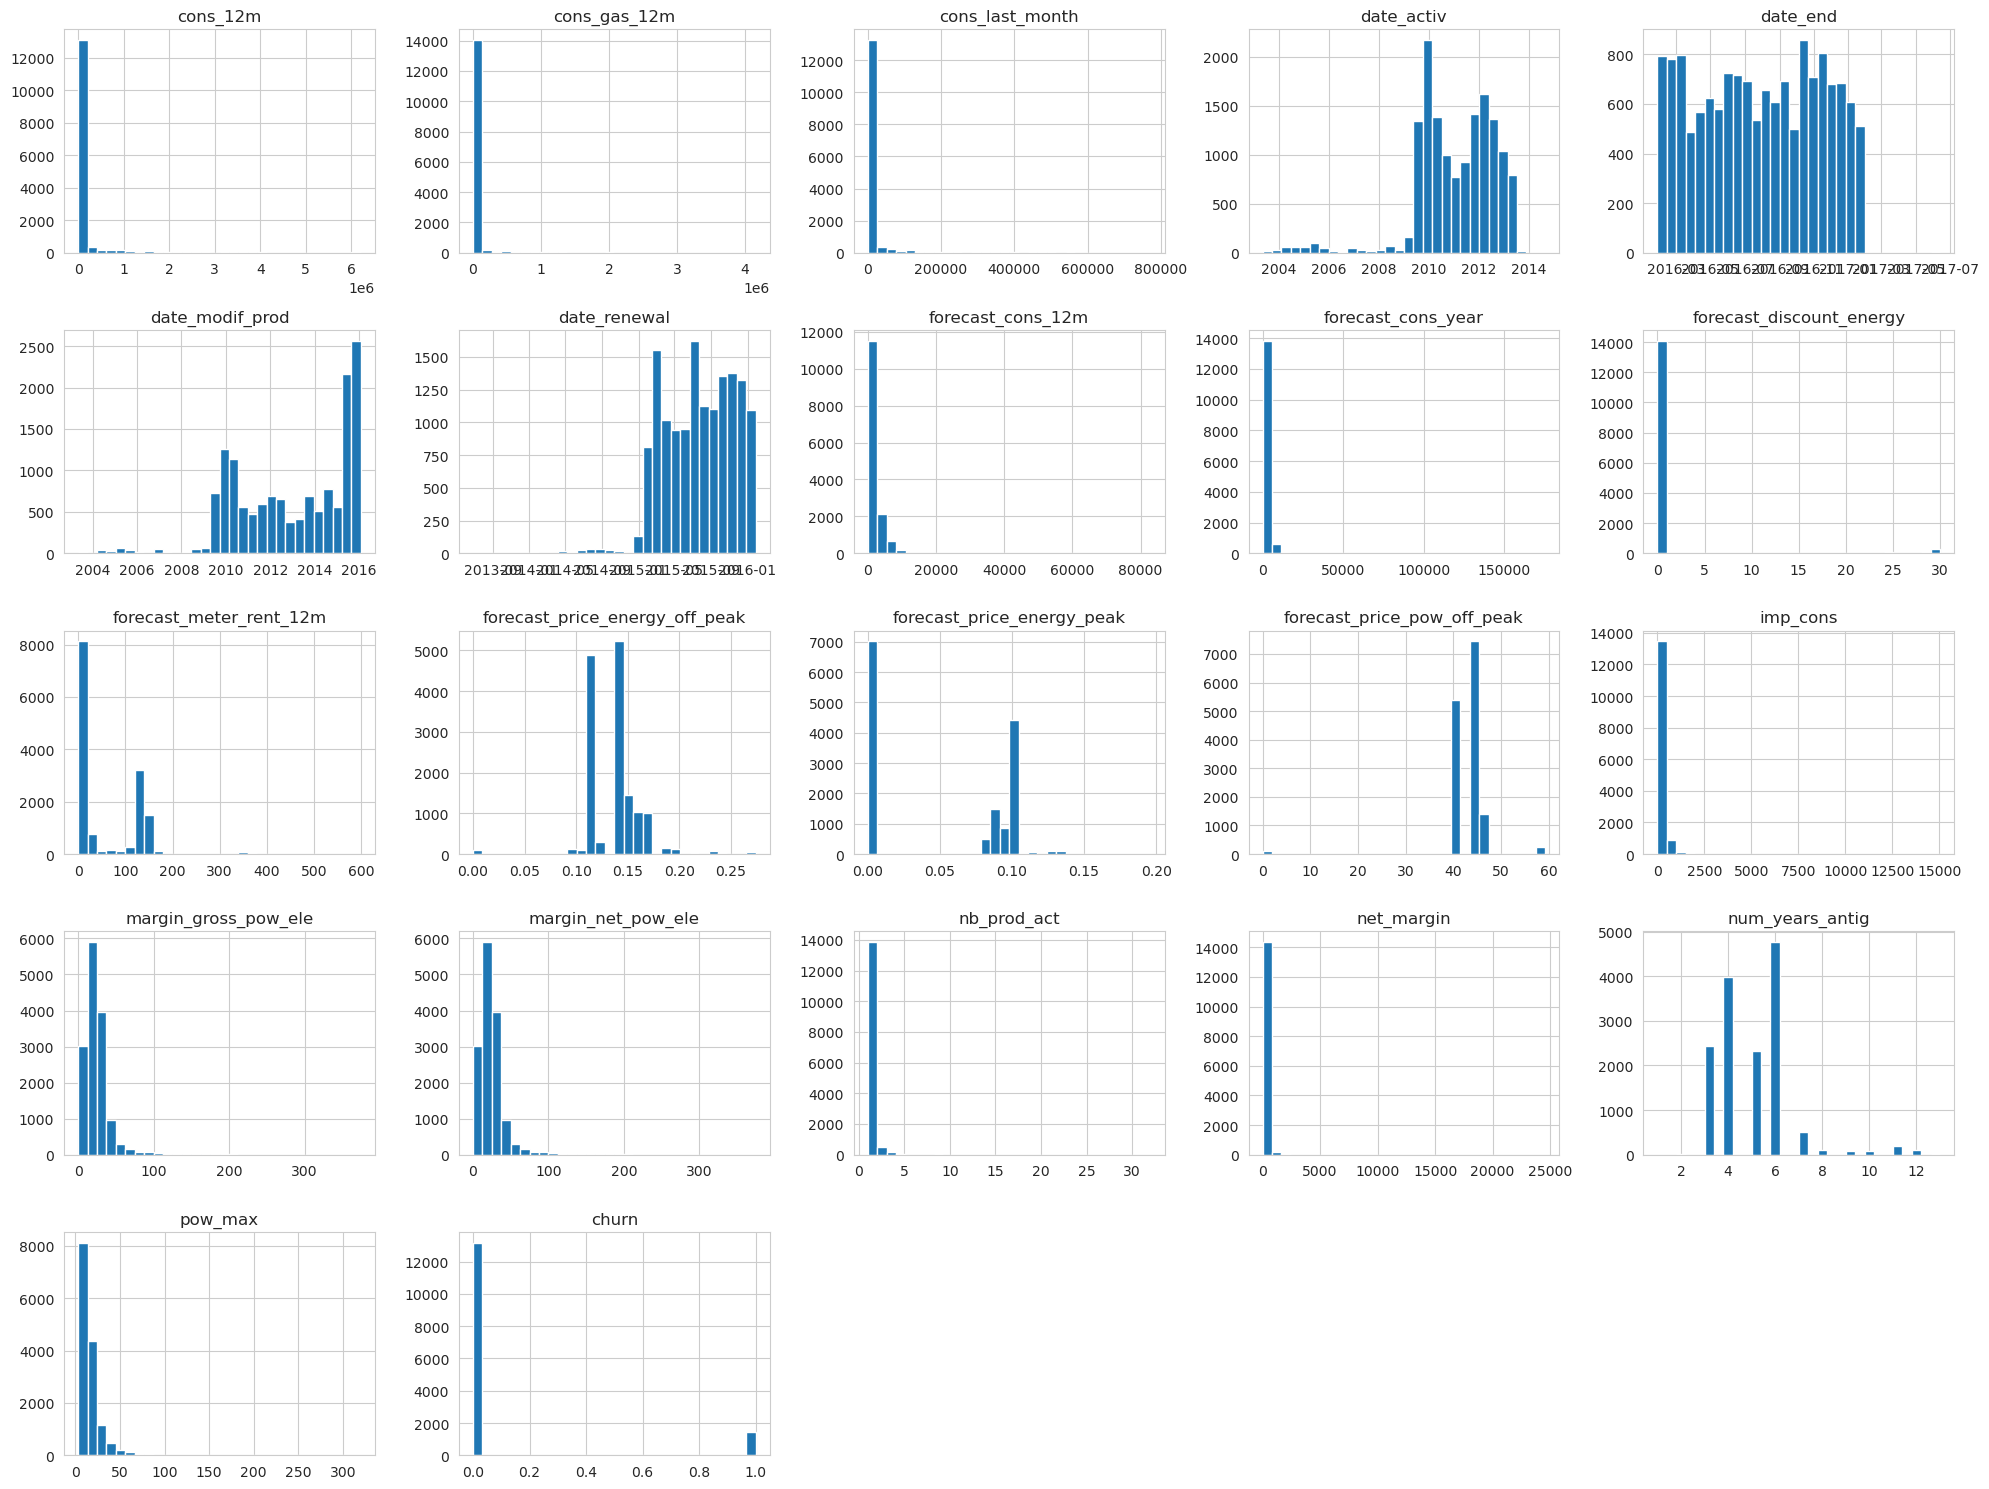

In [30]:
client_df.hist(
    figsize=(20,15),
    bins=30
)

plt.tight_layout()
plt.show()

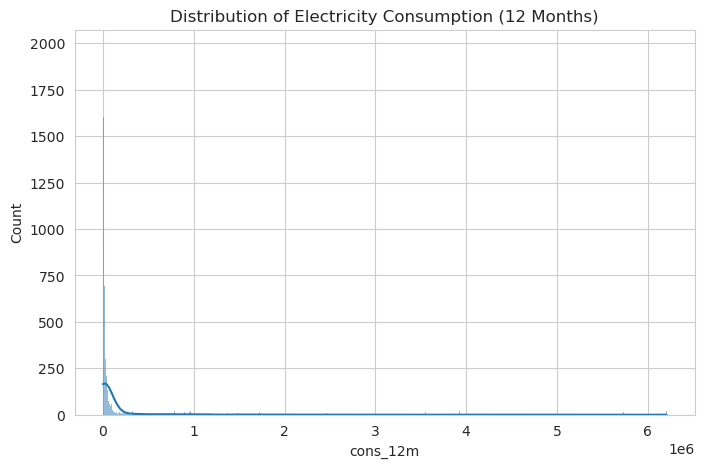

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    client_df['cons_12m'],
    kde=True
)

plt.title("Distribution of Electricity Consumption (12 Months)")
plt.show()

## Detailed Variable Distributions

The following visualisations provide a closer look at individual numerical variables using Seaborn.

Kernel Density Estimation (KDE) curves are included to better understand the underlying shape of each distribution.

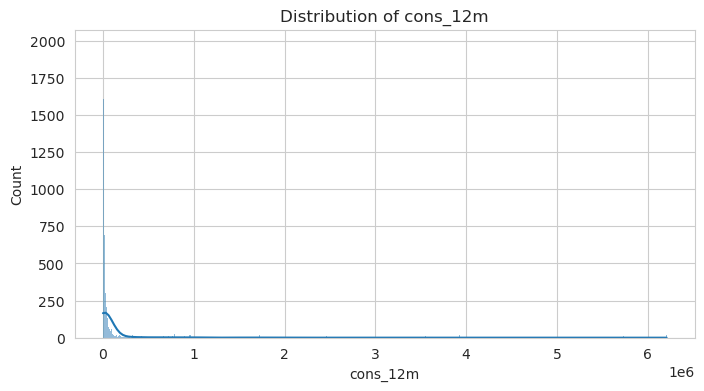

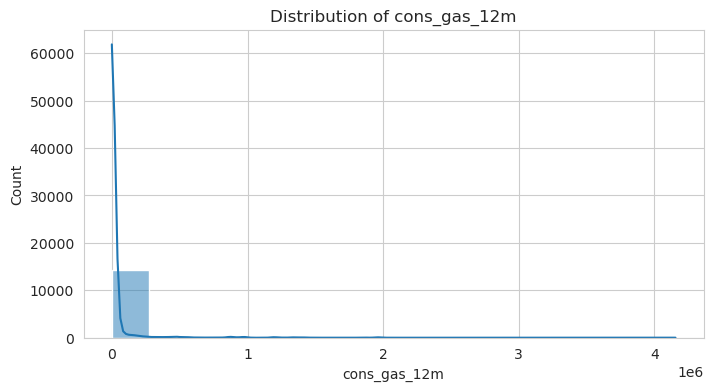

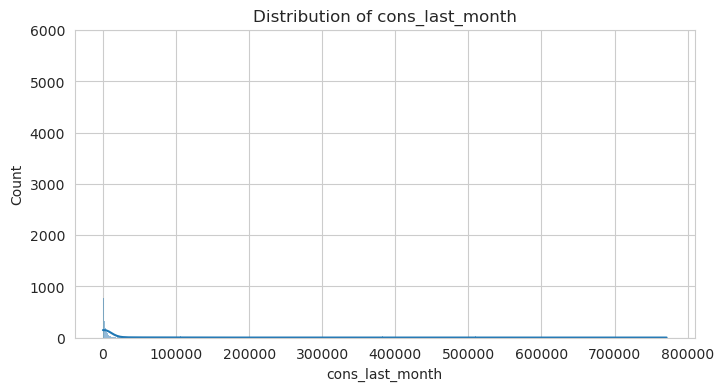

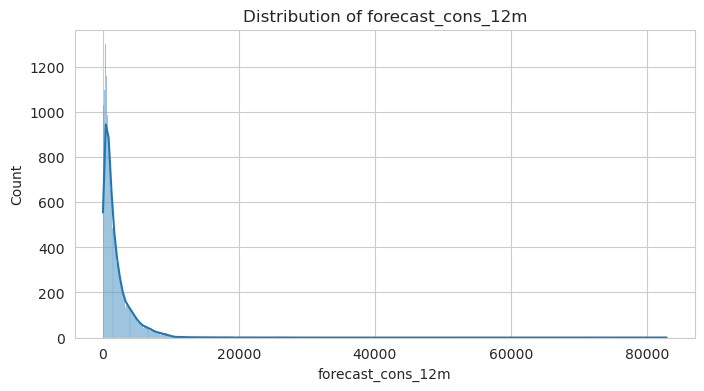

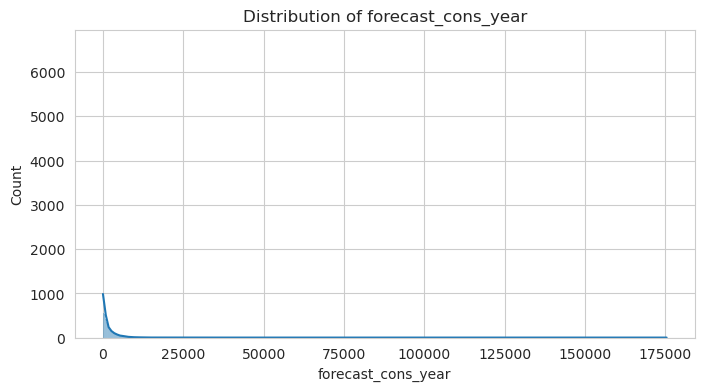

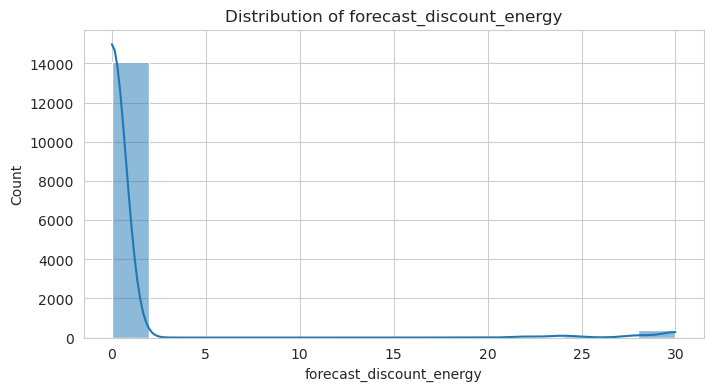

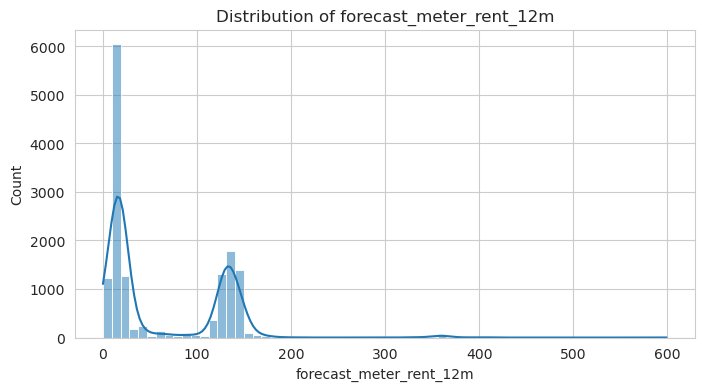

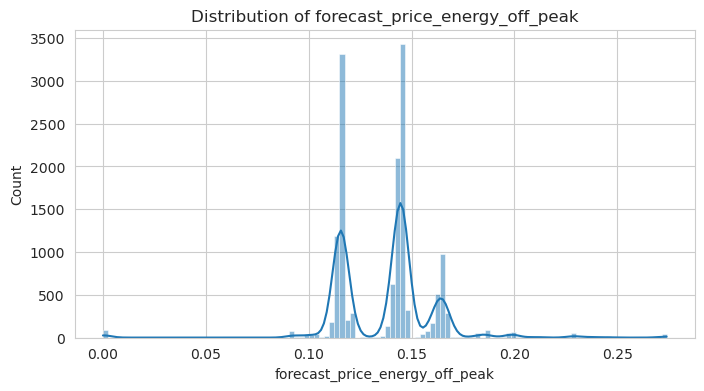

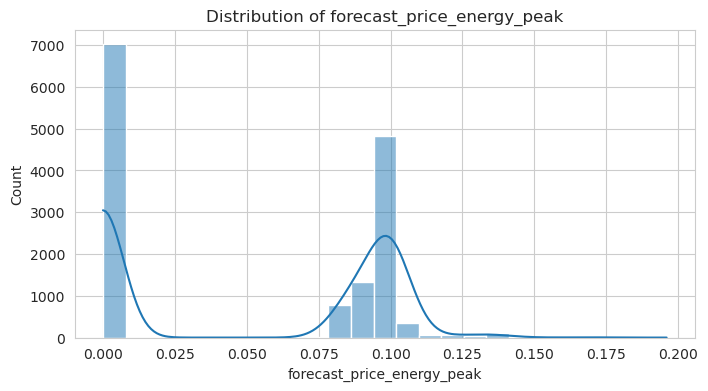

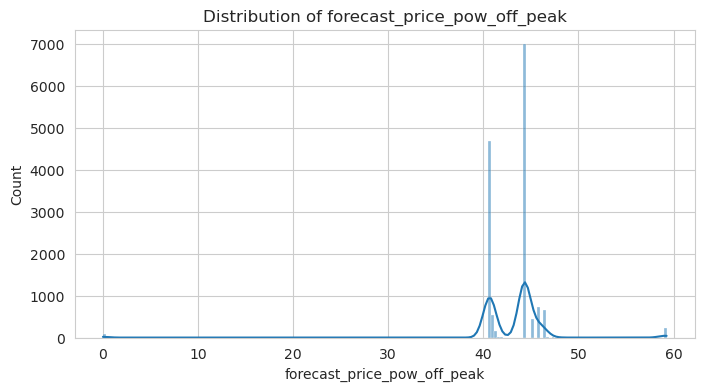

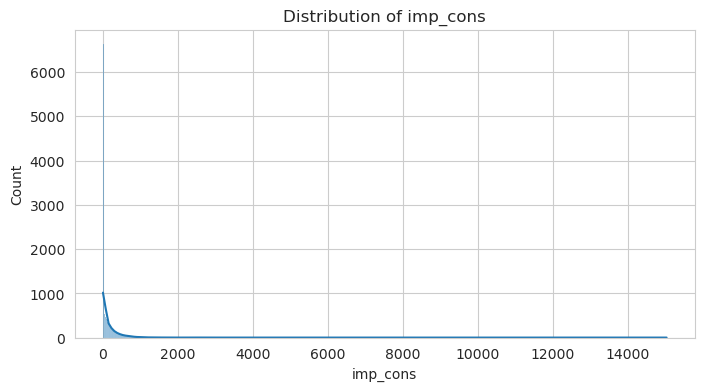

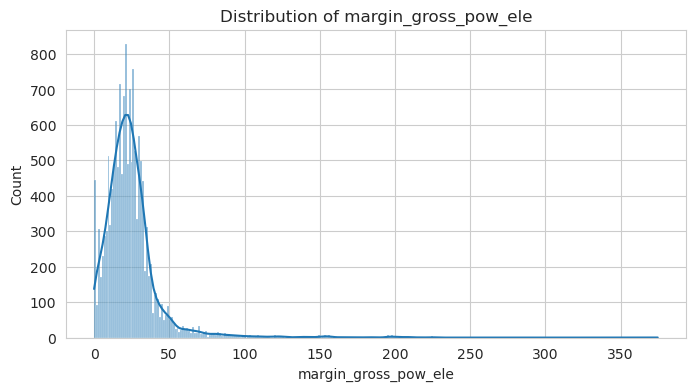

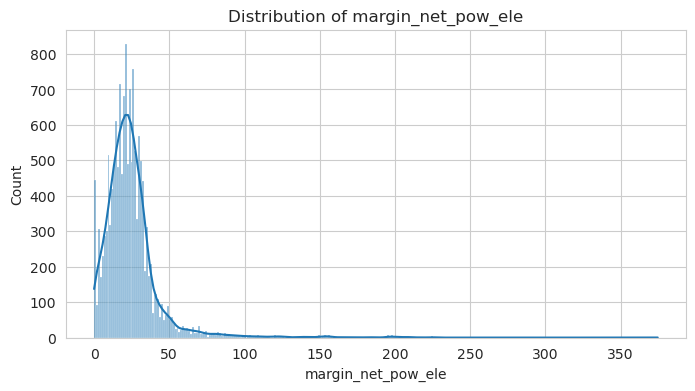

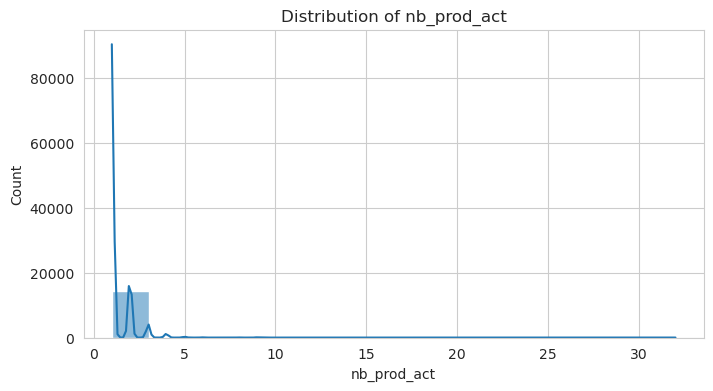

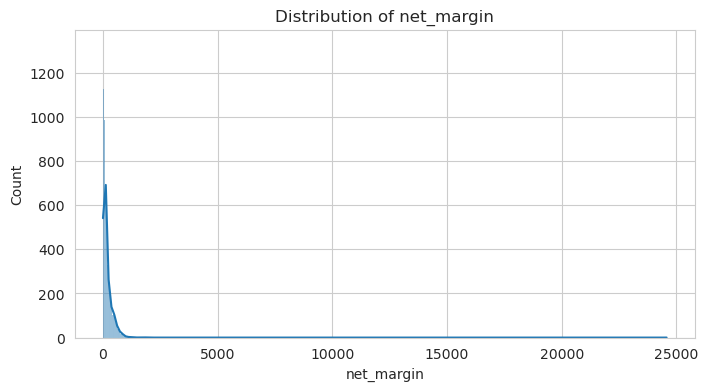

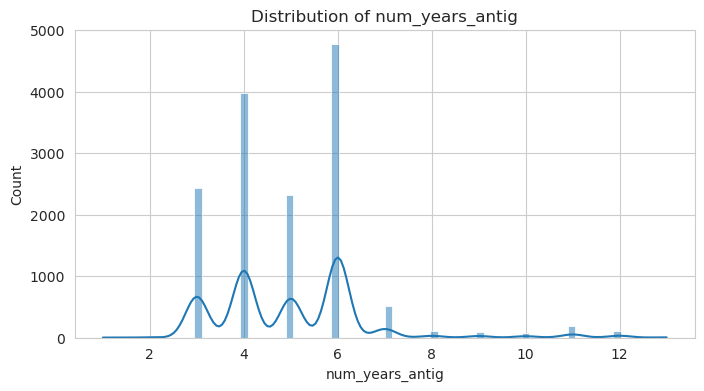

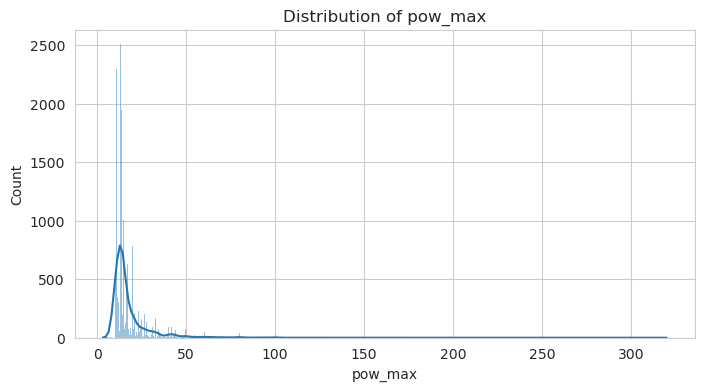

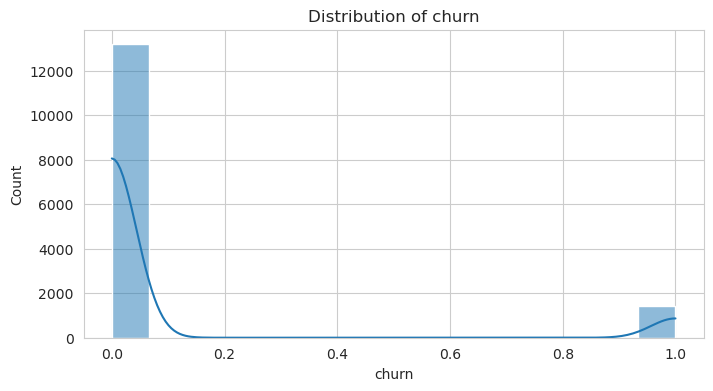

In [32]:
numerical_cols = client_df.select_dtypes(
    include=['int64','float64']
).columns

for col in numerical_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        client_df[col],
        kde=True
    )
    
    plt.title(f'Distribution of {col}')
    plt.show()

## Detecting Outliers

Not all customers behave the same way.

Outlier analysis helps identify unusual consumption patterns, high-value customers and potentially important business cases that deserve further investigation.

These observations can significantly influence both business decisions and predictive modelling performance.

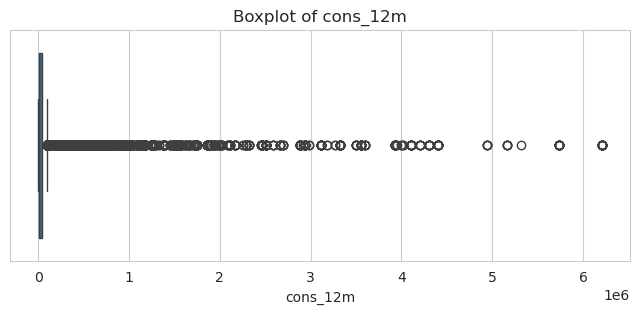

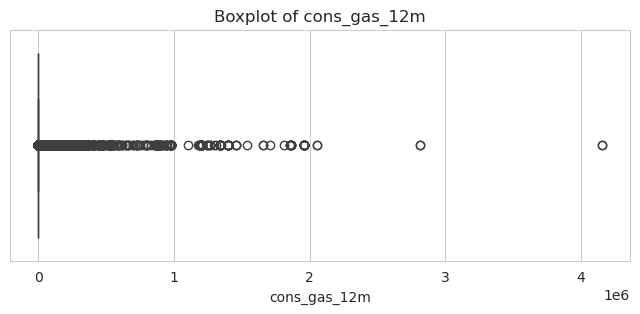

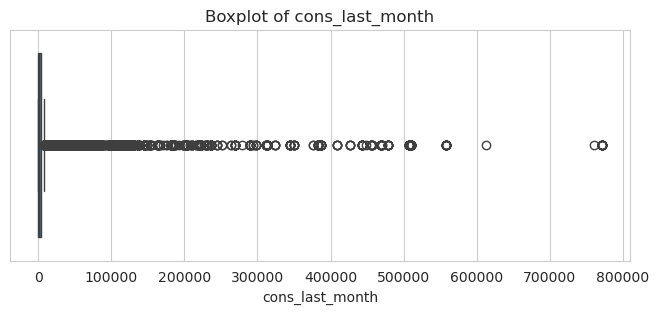

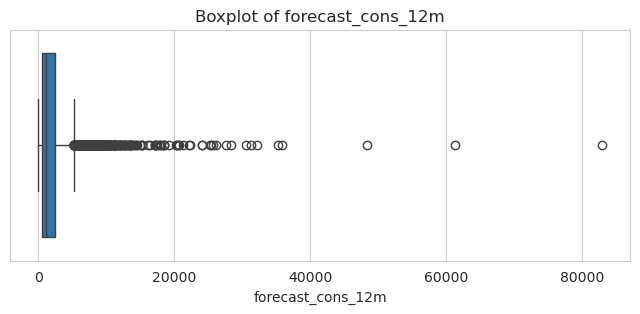

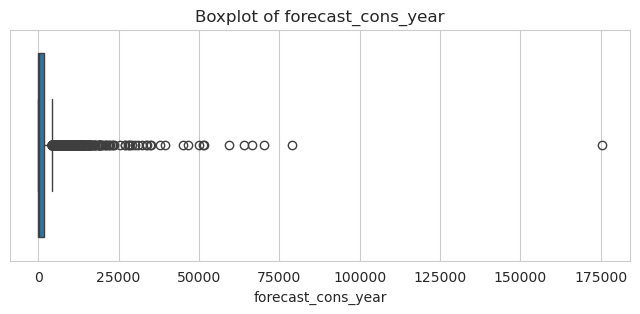

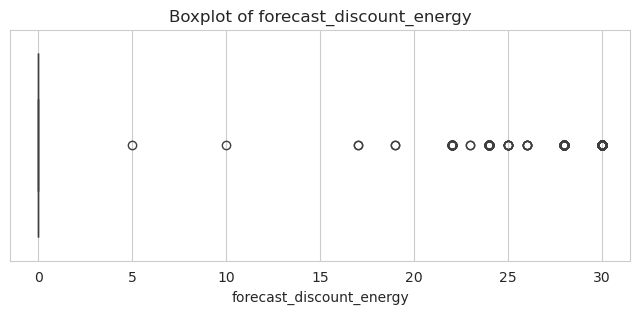

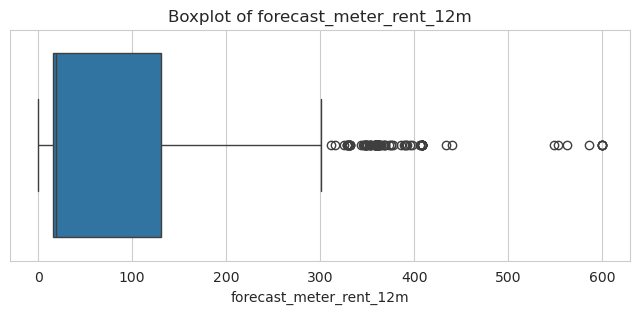

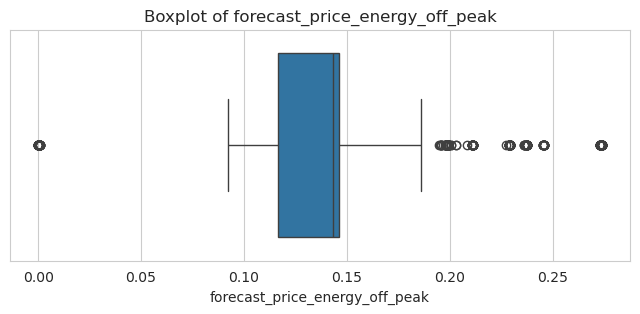

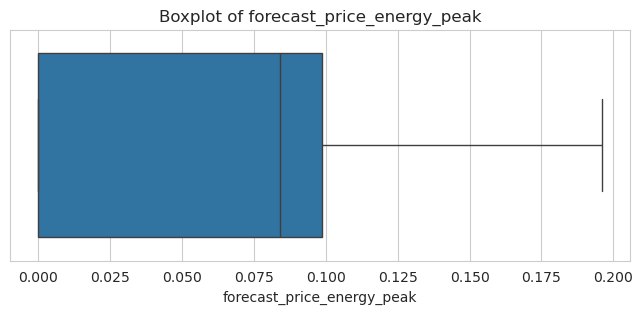

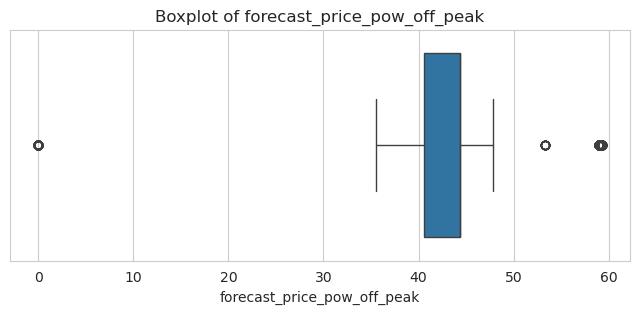

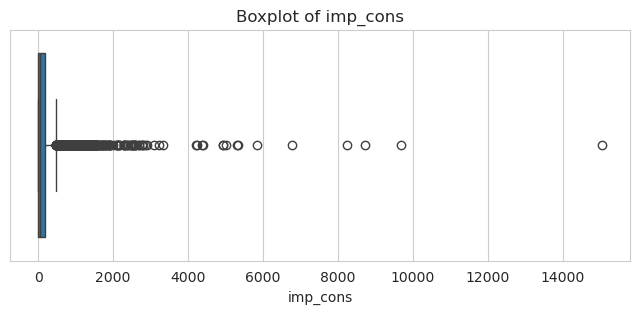

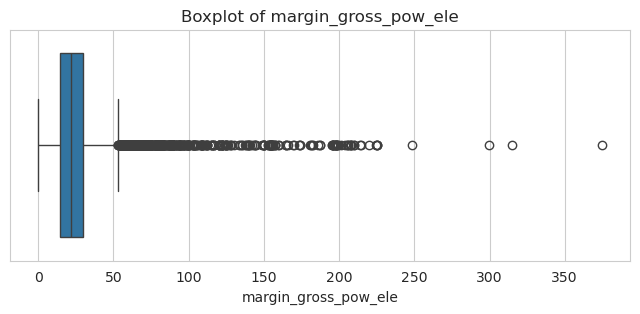

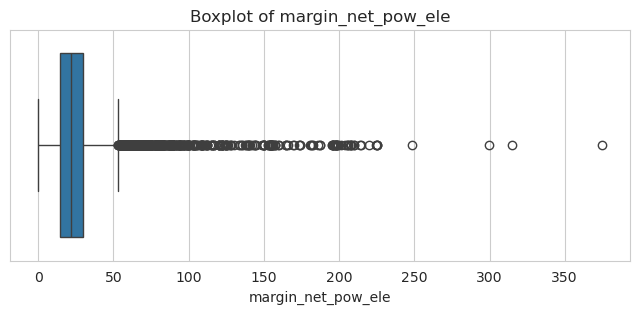

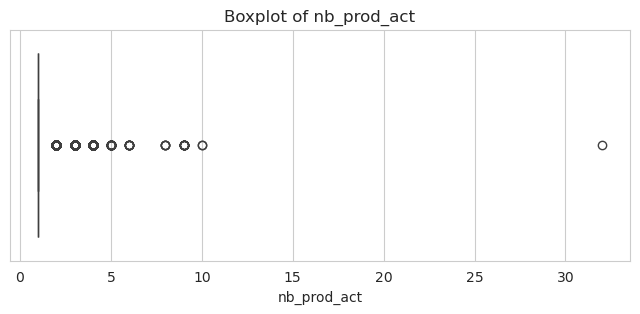

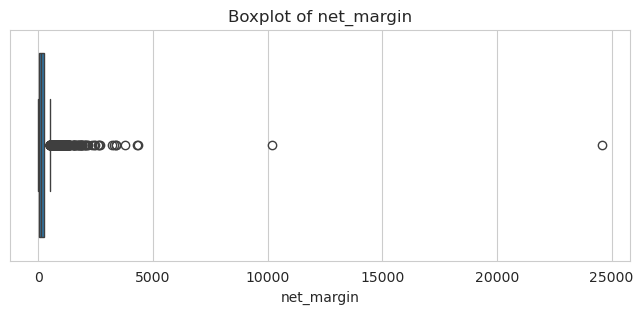

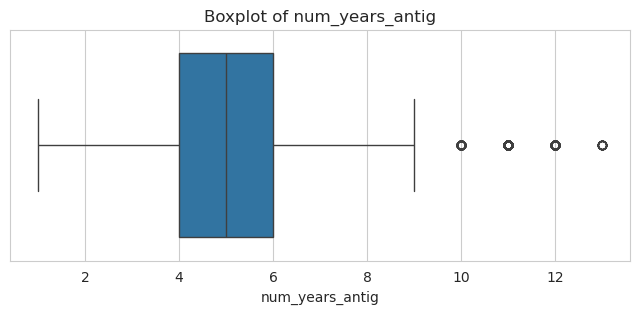

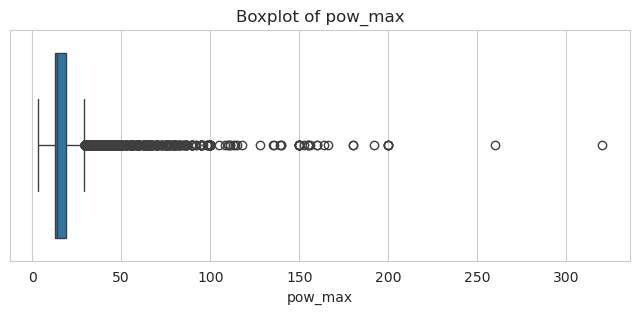

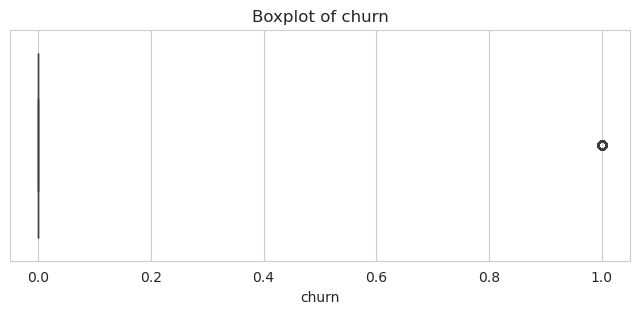

In [33]:
for col in numerical_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(
        x=client_df[col]
    )
    
    plt.title(f'Boxplot of {col}')
    plt.show()

## 🏷 Analysing Categorical Variables

Customer behaviour is often influenced by categorical factors such as:

- Sales channels
- Marketing campaigns
- Customer activities
- Product subscriptions

Understanding these categories helps reveal the composition of the customer base and highlights potential drivers of churn.

In [34]:
categorical_cols = client_df.select_dtypes(
    include=['object']
).columns

categorical_cols

Index(['id', 'channel_sales', 'has_gas', 'origin_up'], dtype='object')

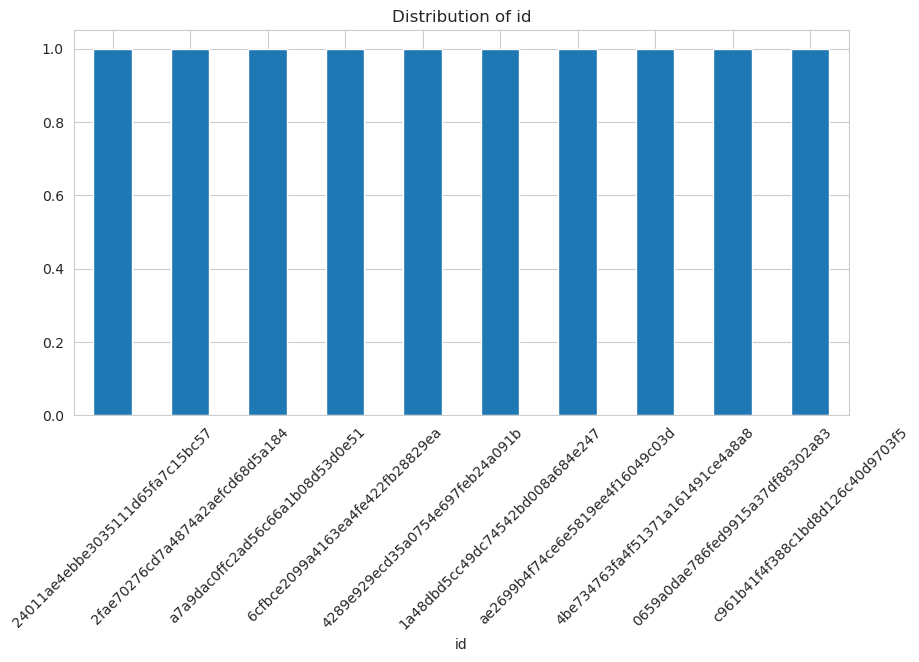

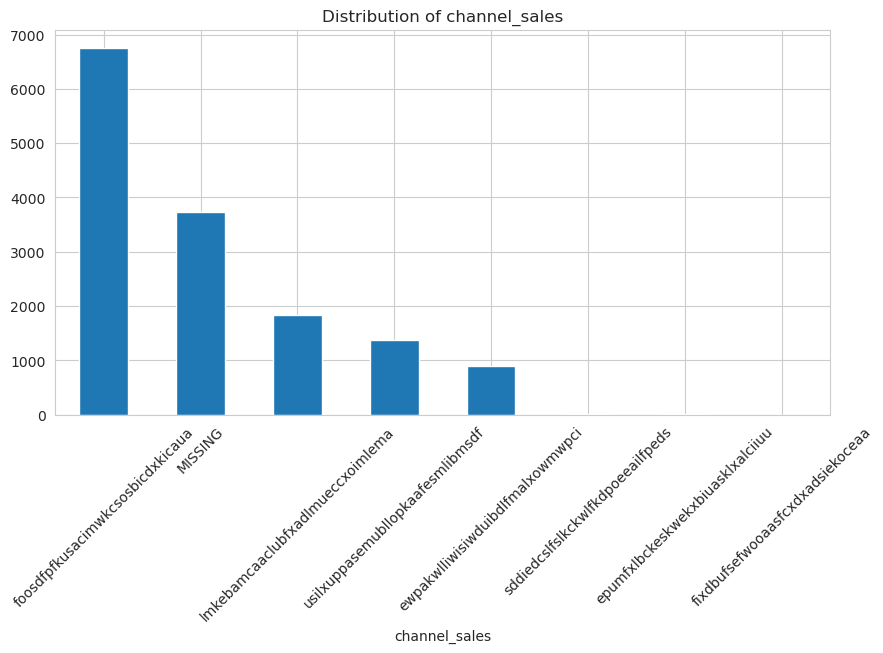

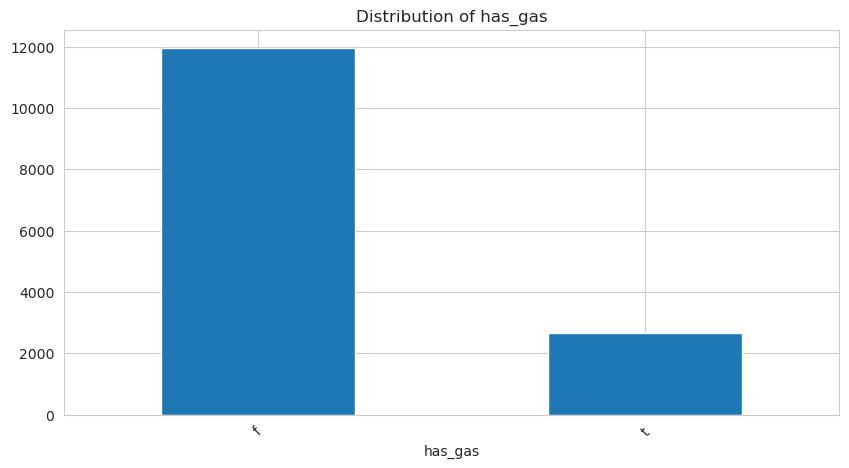

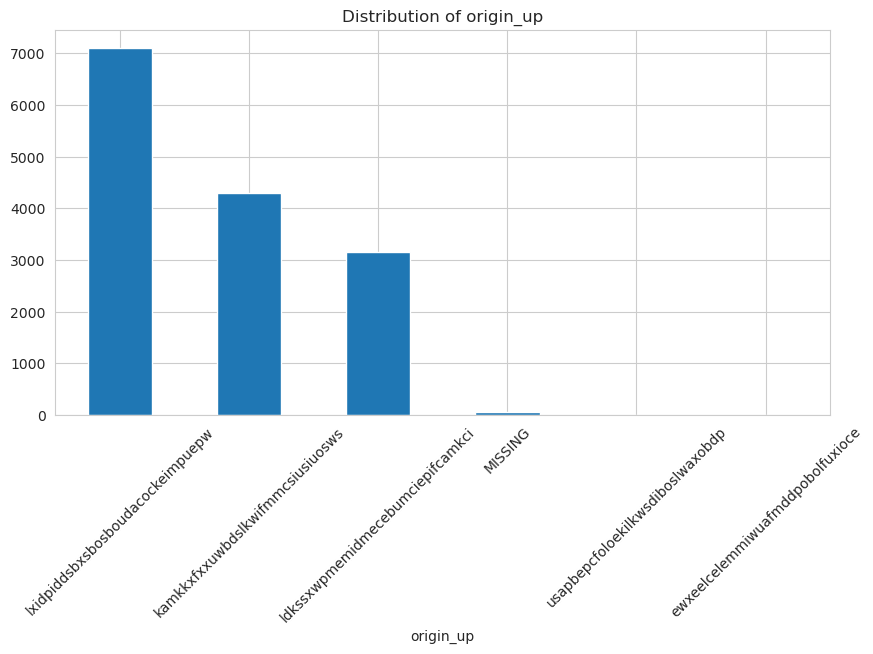

In [35]:
for col in categorical_cols:
    
    plt.figure(figsize=(10,5))
    
    client_df[col].value_counts().head(10).plot(
        kind='bar'
    )
    
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

## Understanding Customer Churn

Customer churn is the primary target variable in this analysis.

Before building predictive models, it is important to understand the balance between customers who remained and those who left.

Questions explored include:

- How common is churn?
- Is the dataset balanced?
- What challenges might this create for predictive modelling?

The answers will guide future modelling decisions.

In [36]:
client_df['churn'].value_counts()

churn
0    13187
1     1419
Name: count, dtype: int64

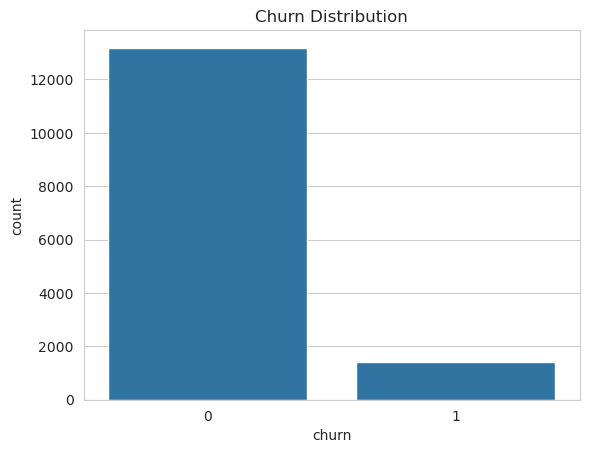

In [37]:
sns.countplot(
    x='churn',
    data=client_df
)

plt.title("Churn Distribution")
plt.show()

In [38]:
client_df['churn'].value_counts(normalize=True) * 100

churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64

## Data Quality Assessment

Reliable analysis depends on reliable data.

This section investigates missing values and data quality issues that could impact analytical results or machine learning performance.

Identifying these issues early helps ensure robust and trustworthy insights.

In [39]:
missing = client_df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(
    ascending=False
)

Series([], dtype: int64)

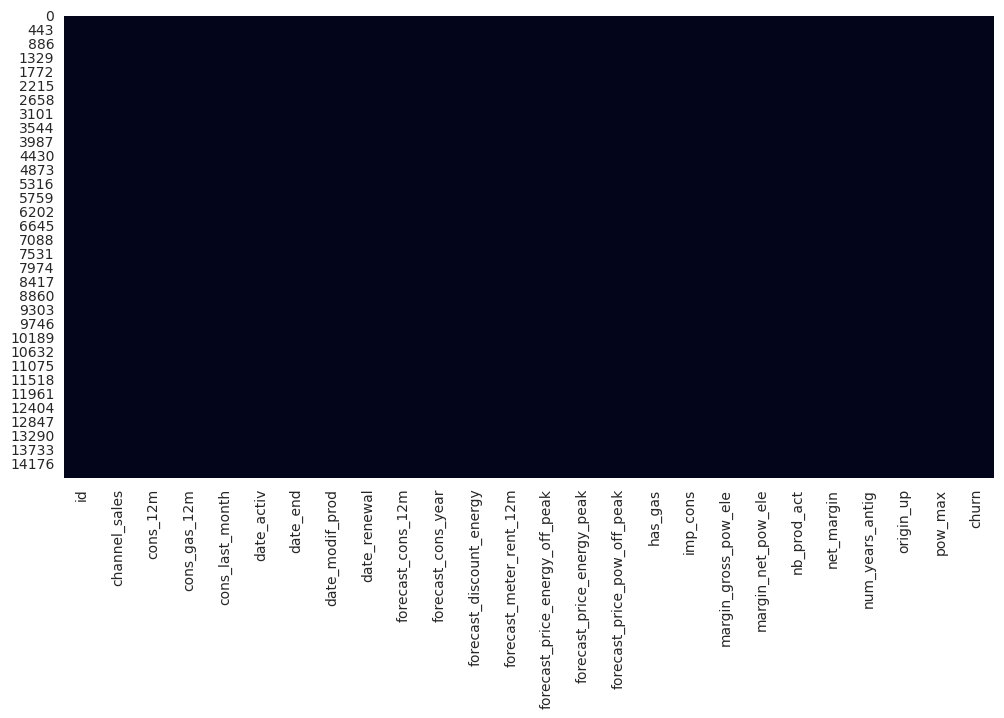

In [40]:
plt.figure(figsize=(12,6))

sns.heatmap(
    client_df.isnull(),
    cbar=False
)

plt.show()

In [ ]:
# 💡 Key Findings and Next Steps

This exploratory analysis provided valuable insights into customer behaviour, consumption patterns and pricing characteristics.

### Key Accomplishments

✅ Loaded and explored customer and pricing datasets

✅ Assessed data quality and variable structure

✅ Investigated numerical and categorical distributions

✅ Examined customer churn behaviour

✅ Identified potential opportunities for feature engineering

### Next Steps

The next phase of this project will focus on:

1. Feature Engineering
2. Correlation Analysis
3. Customer Segmentation
4. Churn Prediction Modelling
5. Business Recommendations

### Business Value

The ultimate objective is to identify customers at risk of churn and provide actionable insights that support customer retention strategies and long-term business growth.

---
**Author:** Bongani Gift Nkosi  
**Project:** Customer Churn Analysis using Python

In [41]:
plt.savefig("churn_distribution.png", bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [42]:
import os

os.listdir()

['Untitled.ipynb',
 'Untitled1.ipynb',
 'churn_distribution.png',
 'client_data (1).csv',
 'price_data (1).csv',
 'marie.png',
 'bar.vl.json',
 'audio.wav',
 'iris.csv',
 'fasta-example.fasta',
 'matplotlib.png',
 'Museums_in_DC.geojson']